# Compact
Load Compact CSV files and create a DataFrame named `df`.

In [1]:
from pathlib import Path
import pandas as pd

def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent):
        if (candidate / "data" / "raw" / "Alternative Medien").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing data/raw/Alternative Medien")

def read_csv_resilient(csv_path: Path) -> pd.DataFrame:
    for encoding in ("utf-8", "utf-8-sig", "latin-1"):
        try:
            return pd.read_csv(
                csv_path,
                encoding=encoding,
                low_memory=False,
                on_bad_lines="skip",
            )
        except Exception:
            pass

    for encoding in ("utf-8", "utf-8-sig", "latin-1"):
        try:
            return pd.read_csv(
                csv_path,
                encoding=encoding,
                sep=None,
                engine="python",
                low_memory=False,
                on_bad_lines="skip",
            )
        except Exception:
            pass

    raise ValueError(f"Could not read: {csv_path}")

PROJECT_ROOT = resolve_project_root()
BASE_DIR = PROJECT_ROOT / "data" / "raw" / "Alternative Medien"

SOURCE_NAME = "Compact"
SOURCE_DIR = BASE_DIR / SOURCE_NAME
csv_files = sorted(SOURCE_DIR.rglob("*.csv"))

parts = []
for csv_file in csv_files:
    part = read_csv_resilient(csv_file)
    part["source"] = SOURCE_NAME
    part["source_file"] = csv_file.name
    parts.append(part)

df = pd.concat(parts, ignore_index=True, sort=False) if parts else pd.DataFrame()
df_clean = df.copy()

print(f"Loaded {len(df)} rows from {len(csv_files)} file(s) in {SOURCE_DIR}")
df_clean.head()

Loaded 2045 rows from 214 file(s) in /Users/MattisHaumann/Dev/Thesis/data/raw/Alternative Medien/Compact


,Date,Title,Inhalt,URL,source,source_file
0,2025-06-11,COMPACT gegen Regierung: So war der 2. Tag!,Der zweite und letzte Verhandlungstag im COMPA...,https://www.compact-online.de/compact-gegen-re...,Compact,Compact_2025-06-11_raw.csv
1,2025-06-11,COMPACT-Verbot 2024: Der Film,Als Nancy Faeser eskalierte. Die denkwürdigste...,https://www.compact-online.de/compact-verbot-2...,Compact,Compact_2025-06-11_raw.csv
2,2025-06-11,Drogen und Rituale: Mysteriöse Inka-Stätte ent...,Ein neuer Fund in den peruanischen Anden eröff...,https://www.compact-online.de/drogen-und-ritua...,Compact,Compact_2025-06-11_raw.csv
3,2025-06-11,Trumps Einsatz in Los Angeles: Ein Medientrauma,Das Durchgreifen des US-Präsidenten gegen das ...,https://www.compact-online.de/trumps-einsatz-i...,Compact,Compact_2025-06-11_raw.csv
4,2025-06-11,Verrat an BismarckCOMPACT+,Essay von Rolf Hochhut. Deutschland hat seinen...,https://www.compact-online.de/verrat-an-bismarck/,Compact,Compact_2025-06-11_raw.csv


In [2]:
# compute and display missing values per column for the cleaned dataframe
missing = df_clean.isna().sum().rename("missing_count").to_frame()
missing["missing_pct"] = (missing["missing_count"] / len(df_clean)) * 100
missing = missing.sort_values("missing_count", ascending=False)
missing

,missing_count,missing_pct
Date,0,0.0
Title,0,0.0
Inhalt,0,0.0
URL,0,0.0
source,0,0.0
source_file,0,0.0


In [3]:
# filter timeframe Aug 2025 through Jan 2026 (inclusive) and keep as df_clean
start, end = "2025-08-01", "2026-01-31"

dates = pd.to_datetime(df_clean["Date"], errors="coerce")
mask = (dates >= pd.Timestamp(start)) & (dates <= pd.Timestamp(end))

df_clean = df_clean.loc[mask].copy()
df_clean["Date"] = pd.to_datetime(df_clean["Date"], errors="coerce")

print(f"Rows in selected period: {len(df_clean)}")
df_clean.sort_values("Date").head()

Rows in selected period: 1614


,Date,Title,Inhalt,URL,source,source_file
344,2025-08-01,Blond! Linker Hass gegen Jeans-Model,"„Blonde Haare, blaue Augen, tolles Erbmaterial...",https://www.compact-online.de/blond-linker-has...,Compact,Compact_2025-08-01_raw.csv
345,2025-08-01,Die Macht der Israel-Lobby in den USA,Die beinharte Unterstützung Donald Trumps für ...,https://www.compact-online.de/die-macht-der-is...,Compact,Compact_2025-08-01_raw.csv
346,2025-08-01,Ein Polizist aus dem Volk,Karsten Hilse im Porträt. Ein Menetekel: Am Ta...,https://www.compact-online.de/ein-polizist-aus...,Compact,Compact_2025-08-01_raw.csv
347,2025-08-01,SPD-Politiker fordert Rückzug von Brosius-Gers...,Die Bundesregierung möchte die politischer Som...,https://www.compact-online.de/spd-politiker-fo...,Compact,Compact_2025-08-01_raw.csv
348,2025-08-01,Die große Vertuschung,"Epstein, Epstein, alles muss versteckt sein: T...",https://www.compact-online.de/die-grosse-vertu...,Compact,Compact_2025-08-01_raw.csv


Date filter

In [4]:
df_clean['Date'].min(), df_clean['Date'].max()

(Timestamp('2025-08-01 00:00:00'), Timestamp('2026-01-31 00:00:00'))

In [5]:
# keep only the requested columns
_keep = ["Date", "Title", "Inhalt", "URL"]

if 'df_clean' in globals():
    df_clean = df_clean.loc[:, _keep].copy()

if 'df_aug2025_jan2026' in globals():
    df_aug2025_jan2026 = df_aug2025_jan2026.loc[:, _keep].copy()

if 'df' in globals():
    df = df.loc[:, _keep].copy()

# show result
df_clean.head()

,Date,Title,Inhalt,URL
344,2025-08-01,Blond! Linker Hass gegen Jeans-Model,"„Blonde Haare, blaue Augen, tolles Erbmaterial...",https://www.compact-online.de/blond-linker-has...
345,2025-08-01,Die Macht der Israel-Lobby in den USA,Die beinharte Unterstützung Donald Trumps für ...,https://www.compact-online.de/die-macht-der-is...
346,2025-08-01,Ein Polizist aus dem Volk,Karsten Hilse im Porträt. Ein Menetekel: Am Ta...,https://www.compact-online.de/ein-polizist-aus...
347,2025-08-01,SPD-Politiker fordert Rückzug von Brosius-Gers...,Die Bundesregierung möchte die politischer Som...,https://www.compact-online.de/spd-politiker-fo...
348,2025-08-01,Die große Vertuschung,"Epstein, Epstein, alles muss versteckt sein: T...",https://www.compact-online.de/die-grosse-vertu...


In [6]:
from IPython.display import display
display(df_clean.head(3))

,Date,Title,Inhalt,URL
344,2025-08-01,Blond! Linker Hass gegen Jeans-Model,"„Blonde Haare, blaue Augen, tolles Erbmaterial...",https://www.compact-online.de/blond-linker-has...
345,2025-08-01,Die Macht der Israel-Lobby in den USA,Die beinharte Unterstützung Donald Trumps für ...,https://www.compact-online.de/die-macht-der-is...
346,2025-08-01,Ein Polizist aus dem Volk,Karsten Hilse im Porträt. Ein Menetekel: Am Ta...,https://www.compact-online.de/ein-polizist-aus...


Removal of "Mehr zum Thema"

In [7]:
import re
def remove_mehr_zum_thema(text):
    if pd.isna(text):
        return text
    
    # Remove everything from "Mehr zum Thema" until end
    cleaned = re.sub(r"\n*\s*Mehr zum Thema.*$", "", text, flags=re.DOTALL)
    return cleaned.strip()

df_clean["Inhalt"] = df_clean["Inhalt"].apply(remove_mehr_zum_thema)

In [8]:
df_clean.head()

,Date,Title,Inhalt,URL
344,2025-08-01,Blond! Linker Hass gegen Jeans-Model,"„Blonde Haare, blaue Augen, tolles Erbmaterial...",https://www.compact-online.de/blond-linker-has...
345,2025-08-01,Die Macht der Israel-Lobby in den USA,Die beinharte Unterstützung Donald Trumps für ...,https://www.compact-online.de/die-macht-der-is...
346,2025-08-01,Ein Polizist aus dem Volk,Karsten Hilse im Porträt. Ein Menetekel: Am Ta...,https://www.compact-online.de/ein-polizist-aus...
347,2025-08-01,SPD-Politiker fordert Rückzug von Brosius-Gers...,Die Bundesregierung möchte die politischer Som...,https://www.compact-online.de/spd-politiker-fo...
348,2025-08-01,Die große Vertuschung,"Epstein, Epstein, alles muss versteckt sein: T...",https://www.compact-online.de/die-grosse-vertu...


In [9]:
# rename column "Inhalt" to "Text"
if "Inhalt" in df_clean.columns:
    df_clean = df_clean.rename(columns={"Inhalt": "Text"})

df_clean.head()

,Date,Title,Text,URL
344,2025-08-01,Blond! Linker Hass gegen Jeans-Model,"„Blonde Haare, blaue Augen, tolles Erbmaterial...",https://www.compact-online.de/blond-linker-has...
345,2025-08-01,Die Macht der Israel-Lobby in den USA,Die beinharte Unterstützung Donald Trumps für ...,https://www.compact-online.de/die-macht-der-is...
346,2025-08-01,Ein Polizist aus dem Volk,Karsten Hilse im Porträt. Ein Menetekel: Am Ta...,https://www.compact-online.de/ein-polizist-aus...
347,2025-08-01,SPD-Politiker fordert Rückzug von Brosius-Gers...,Die Bundesregierung möchte die politischer Som...,https://www.compact-online.de/spd-politiker-fo...
348,2025-08-01,Die große Vertuschung,"Epstein, Epstein, alles muss versteckt sein: T...",https://www.compact-online.de/die-grosse-vertu...


Duplicates

In [10]:
# Columns to check for duplicate records
dup_cols = ["Title"]

# Find duplicates (all rows that belong to duplicate groups)
dup_mask = df_clean.duplicated(subset=dup_cols, keep=False)
dups = df_clean.loc[dup_mask].sort_values(dup_cols)

print(f"Number of duplicate rows (across {dup_cols}): {len(dups)}")

# optional preview
dups.head()

Number of duplicate rows (across ['Title']): 75


,Date,Title,Text,URL
1015,2025-10-20,15 Jahre COMPACT: Die Jubiläums-Gala,Am 31. Januar 2026 feiern wir in Magdeburg den...,https://www.compact-online.de/15-jahre-compact...
1114,2025-10-29,15 Jahre COMPACT: Die Jubiläums-Gala,Am 31. Januar 2026 feiern wir in Magdeburg den...,https://www.compact-online.de/15-jahre-compact...
1193,2025-11-09,15 Jahre COMPACT: Die Jubiläums-Gala,Am 31. Januar 2026 feiern wir in Magdeburg den...,https://www.compact-online.de/15-jahre-compact...
795,2025-09-28,5 vor 12: Beginnt nächste Woche Krieg?,Achtung Kriegsgefahr! Während europäische Länd...,https://www.compact-online.de/5-vor-12-beginnt...
786,2025-09-27,5 vor 12: Beginnt nächste Woche Krieg?,Achtung Kriegsgefahr! Während europäische Länd...,https://www.compact-online.de/5-vor-12-beginnt...


In [11]:
# remove duplicates if either Title OR Inhalt is duplicated
dup_title = df_clean.duplicated(subset=["Title"], keep="first")
dup_text = df_clean.duplicated(subset=["Text"], keep="first")
dup_any = dup_title | dup_text

dups = df_clean.loc[dup_any].copy()      # removed duplicate rows
df_clean = df_clean.loc[~dup_any].copy() # keep only unique rows

print(f"Removed duplicates: {dup_any.sum()}")
print(f"Remaining rows: {len(df_clean)}")

df_clean.head()

Removed duplicates: 50
Remaining rows: 1564


,Date,Title,Text,URL
344,2025-08-01,Blond! Linker Hass gegen Jeans-Model,"„Blonde Haare, blaue Augen, tolles Erbmaterial...",https://www.compact-online.de/blond-linker-has...
345,2025-08-01,Die Macht der Israel-Lobby in den USA,Die beinharte Unterstützung Donald Trumps für ...,https://www.compact-online.de/die-macht-der-is...
346,2025-08-01,Ein Polizist aus dem Volk,Karsten Hilse im Porträt. Ein Menetekel: Am Ta...,https://www.compact-online.de/ein-polizist-aus...
347,2025-08-01,SPD-Politiker fordert Rückzug von Brosius-Gers...,Die Bundesregierung möchte die politischer Som...,https://www.compact-online.de/spd-politiker-fo...
348,2025-08-01,Die große Vertuschung,"Epstein, Epstein, alles muss versteckt sein: T...",https://www.compact-online.de/die-grosse-vertu...


In [12]:
compact_clean = df_clean.copy()
compact_clean["source"] = "Compact"
compact_clean = compact_clean[["Date", "Title", "Text", "source"]].copy()
compact_clean.to_csv("compact_clean.csv", index=False, encoding="utf-8")

In [13]:
# check presence of the exact footer sentence in df_clean["Text"]
# relies on df_clean already being defined in the notebook

# the exact sentence (copy-paste from your prompt)
footer = "⁠In diesem Artikel wird u. a. auf Produkte der 9 Leben GmbH verlinkt. Für diese Links erhält COMPACT keinerlei Vergütungen."

# normalize by removing common zero-width characters that may be present
_zero_width_re = r"[\u200B\u200C\u200D\u2060]"
_texts = df_clean["Text"].astype("string").fillna("")
_texts_norm = _texts.str.replace(_zero_width_re, "", regex=True).str.strip()
_footer_norm = re.sub(_zero_width_re, "", footer)

# boolean mask for rows where the text ends with the exact footer (after normalization)
has_footer = _texts_norm.str.endswith(_footer_norm)

# show counts (True = contains exact footer, False = does not)
print("Presence value counts:")
print(has_footer.value_counts(dropna=False))

# optional: inspect a few matching rows (Date, Title) to verify
print("\nSample matching rows:")
display(df_clean.loc[has_footer, ["Date", "Title", "URL"]].head(10))

Presence value counts:
Text
False    1494
True       70
Name: count, dtype: Int64

Sample matching rows:


,Date,Title,URL
358,2025-08-03,Geheimtipp! Warum ohne diesen Stoff nichts meh...,https://www.compact-online.de/immer-noch-ein-g...
380,2025-08-05,Länger jung und schön! Hat dieses Mittel Wunde...,https://www.compact-online.de/mit-der-kraft-de...
392,2025-08-07,Der große Vitamin-Irrtum: Wenn Gesundes falsch...,https://www.compact-online.de/der-grosse-vitam...
433,2025-08-12,Warum diese Zeichen mehr Energie & Gesundheit ...,https://www.compact-online.de/warum-q10-nicht-...
448,2025-08-21,Lebenswichtiges Hormon – Fluch und Segen zugleich,https://www.compact-online.de/ein-lebenswichti...
468,2025-08-24,Wie man mit diesem Mineral sogar den Krebs bes...,https://www.compact-online.de/wie-man-mit-eine...
523,2025-08-28,Hohes Herz-Risiko! Bluthochdruck wird Volkskra...,https://www.compact-online.de/lebenszeit-verla...
550,2025-08-31,Chronische Schmerzen? Natürliche Alternativen ...,https://www.compact-online.de/gefragt-wie-nie-...
566,2025-09-02,Was das Altern hinauszögert und unsere Zellen ...,https://www.compact-online.de/was-unsere-zelle...
589,2025-09-04,Immunsystem gegen Infektionen unbesiegbar machen,https://www.compact-online.de/gegen-die-corona...


In [ ]:
# plot article volume and length over time (uses eda_df, start, end already defined in the notebook)
df_time = eda_df.copy()

# ensure article length column exists
if "article_length_words" not in df_time.columns:
    df_time["article_length_words"] = df_time[text_col].astype("string").str.split().str.len()

# aggregate per day
daily = (
    df_time.set_index("Date")
    .resample("D")
    .agg(article_count=("Title", "count"),
         mean_words=("article_length_words", "mean"),
         median_words=("article_length_words", "median"))
)

# restrict to selected interval if available
if "start" in globals() and "end" in globals():
    daily = daily.loc[pd.to_datetime(start) : pd.to_datetime(end)]

fig, ax = plt.subplots(figsize=(12, 6))

# articles per day as bar (left y-axis)
ax.bar(daily.index, daily["article_count"], color="#9ecae1", alpha=0.7, width=0.8, label="Articles / day")
ax.set_ylabel("Articles per day", color="#08519c")
ax.tick_params(axis="y", labelcolor="#08519c")

# word-length trends on right y-axis
ax2 = ax.twinx()
ax2.plot(daily.index, daily["median_words"].rolling(7, min_periods=1).mean(), color="#d62728", linestyle="--", linewidth=2, label="7-day rolling median words")
ax2.plot(daily.index, daily["mean_words"].rolling(7, min_periods=1).mean(), color="#2ca02c", linestyle="-.", linewidth=1.5, label="7-day rolling mean words")
ax2.set_ylabel("Words per article (7d rolling)", color="#2ca02c")
ax2.tick_params(axis="y", labelcolor="#2ca02c")

# legends and formatting
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines + lines2, labels + labels2, loc="upper left")
ax.set_title("Compact — article volume and length over time")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## EDA

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)

eda_df = df_clean.copy() if "df_clean" in globals() else df.copy()
eda_df["Date"] = pd.to_datetime(eda_df["Date"], errors="coerce")

text_col = "Text"
eda_df[text_col] = eda_df[text_col].astype("string")
eda_df = eda_df.dropna(subset=["Date", text_col]).copy()

print(f"Rows used for EDA: {len(eda_df):,}")

Rows used for EDA: 1,564


In [15]:
eda_df["article_length_words"] = eda_df[text_col].str.split().str.len()
eda_df["article_length_chars"] = eda_df[text_col].str.len()

eda_df["article_length_words"].describe(
    percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
).round(1)

count    1564.0
mean      495.4
std       484.3
min        23.0
10%        69.0
25%       118.0
50%       420.5
75%       668.8
90%      1111.5
95%      1483.8
99%      2218.8
max      4324.0
Name: article_length_words, dtype: float64

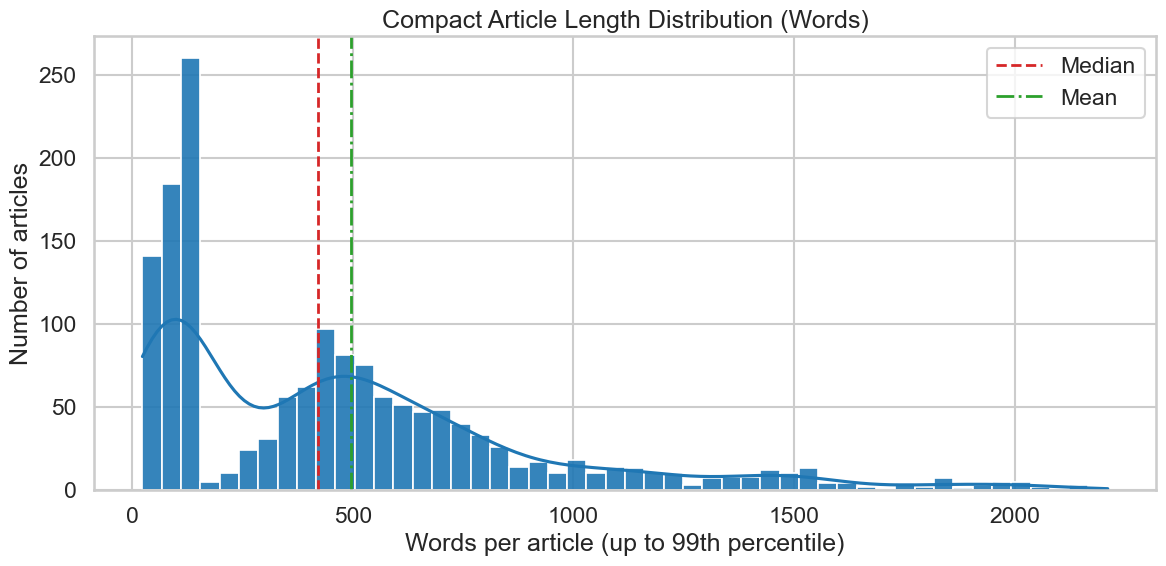

In [16]:
q99 = eda_df["article_length_words"].quantile(0.99)
length_plot = eda_df[eda_df["article_length_words"] <= q99]

fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(
    length_plot["article_length_words"],
    bins=50,
    kde=True,
    color="#1f77b4",
    edgecolor="white",
    alpha=0.9,
    ax=ax,
)

ax.axvline(eda_df["article_length_words"].median(), color="#d62728", linestyle="--", linewidth=2, label="Median")
ax.axvline(eda_df["article_length_words"].mean(), color="#2ca02c", linestyle="-.", linewidth=2, label="Mean")
ax.set_title("Compact Article Length Distribution (Words)")
ax.set_xlabel("Words per article (up to 99th percentile)")
ax.set_ylabel("Number of articles")
ax.legend()
plt.tight_layout()
plt.show()

In [17]:
# Inspect 20 shortest articles by word count
df_inspect = eda_df if "eda_df" in globals() else df_clean.copy()

if "article_length_words" not in df_inspect.columns:
    df_inspect["article_length_words"] = df_inspect["Text"].astype("string").str.split().str.len()

# ensure source column exists (most data is from SOURCE_NAME == "Compact")
if "source" not in df_inspect.columns:
    df_inspect["source"] = SOURCE_NAME if "SOURCE_NAME" in globals() else "Compact"

# build result (Title, text, source, word_count) sorted ascending
shortest = (
    df_inspect.sort_values("article_length_words", ascending=True)
    .loc[:, ["Title", "Text", "source", "article_length_words"]]
    .head(20)
    .rename(columns={"Text": "text", "article_length_words": "word_count"})
)

# allow longer text columns to be displayed
pd.options.display.max_colwidth = 1000

display(shortest)

,Title,text,source,word_count
632,Macron am Boden: Live beim Aufstand!,Frankreich im Ausnahmezustand – COMPACT ist live vor Ort dabei!\n\nCOMPACT-TV ist für Sie gratis! Bitte spenden Sie zu unserer Unterstützung unter compact-online.de/unterstuetzen.,Compact,23
594,Albaner (18) sticht auf Lehrerin ein! NOT-OP!,Amoklauf in Essener Schule. SEK muss schießen. Dr. Stephanie Elsässer klärt auf!\n\nCOMPACT-TV ist für Sie gratis! Bitte spenden Sie zu unserer Unterstützung unter compact-online.de/unterstuetzen.,Compact,25
646,MOSSAD und 9/11,Heute vor 24 Jahren: Israelische Geheimdienstler wurden nach den Anschlägen des 11. September 2001 vom FBI festgenommen und zwei Monate eingesperrt. Waren sie in das Terrorkomplott verwickelt?,Compact,27
464,„Remigration!“: Söder-Interview wird abgebrochen!,Aufregung am Bundestag! Das Sommer-Interview der ARD mit CSU-Chef Söder muss abgebrochen werden.\n\nWir sind vor Ort!\n\nCOMPACT-TV ist für Sie gratis! Bitte spenden Sie zu unserer Unterstützung unter compact-online.de/unterstuetzen.,Compact,30
1187,Halle (Saale): Antifa brüllt gegen Buchmesse,"Wirbel um die «Seitenwechsel»-Buchmesse in Halle (Saale).\n\nSehen Sie hier brüllende Antifas, spannende Interviews und Impressionen von unserem Messestand!\n\nCOMPACT-TV ist für Sie gratis! Bitte spenden Sie zu unserer Unterstützung unter compact-online.de/unterstuetzen.",Compact,32
1388,AfD-Jugend: COMPACT beim Kampf um Gießen!,"Ausnahmezustand in Gießen: Tausende Antifa wollen den Gründungskongress der AfD-Jugend stürmen! Blockaden, Wasserwerfer, Angriffe auf Polizisten und Teilnehmer. COMPACT mittendrin!\n\nCOMPACT-TV ist für Sie gratis! Bitte spenden Sie zu unserer Unterstützung unter compact-online.de/unterstuetzen.",Compact,33
1901,Vor Ort: Orban geht gegen Hammerbande vor!,"In Budapest strebt der Prozess gegen Hammerbanden-„Maja“ seinem Höhepunkt entgegen. Unser Korrespondent Sebastian Schmidtke ist dabei und dokumentiert, wie deutsche Politiker vor Ort Stimmung machen.\n\nDie Reportage sehen Sie in dem Video oben.",Compact,33
1575,Gefahr Migration: Ex-Islamist packt aus!,Irfan Peci war Propaganda-Chef der deutschen al-Qaida! Inzwischen hat er zum christlichen Glauben gefunden und warnt vor den schrecklichen Folgen der Massenmigration. Was steht Deutschland bevor?\n\nUnsere heutige Shop-Empfehlung: „COMPACT-Spezial 45: Mädchen. Messer. Morde“,Compact,34
1656,Rückblick: Unsere größten TV-Highlights!,Nur noch wenige Stunden… – 2025 war ein spektakuläres Jahr mit vielen Höhen und Tiefen. In unserem COMPACT-Rückblick sehen Sie die wichtigsten Ereignisse in einer kurzweiligen Zusammenfassung. Wir wünschen einen frohen Jahreswechsel und ein gesundes Neues!,Compact,36
1692,Spreewald: Wird SIE die erste AfD-Landrätin?,Widerstand im Gurkenland: Der Kreis Oberspreewald-Lausitz gilt als AfD-Hochburg. In wenigen Tagen wird hier ein neuer Landrat gewählt. Die blaue Kandidatin hat gute Chancen. Paul Klemm hat sie mit der Kamera begleitet.\n\nUnsere heutige Produktempfehlung: Silbermedaille Höcke-Taler,Compact,37


--> This indicates two types of documents in the corpus: News briefs / ticker posts and Normal articles

In [18]:
# fig, ax = plt.subplots(figsize=(14, 6))
# ax.bar(
#     daily_counts["Date"],
#     daily_counts["articles"],
#     color="#9ecae1",
#     alpha=0.8,
#     width=1.0,
#     label="Daily articles",
# )
# ax.plot(
#     daily_counts["Date"],
#     daily_counts["rolling_7d"],
#     color="#08519c",
#     linewidth=2.5,
#     label="7-day average",
# )

# ax.set_title("Compact Articles Per Day")
# ax.set_xlabel("Date")
# ax.set_ylabel("Number of articles")
# ax.spines["top"].set_visible(False)
# ax.spines["right"].set_visible(False)
# ax.legend(frameon=True)
# plt.tight_layout()
# plt.show()

In [19]:
compact_clean = df_clean.copy()

if "Inhalt" in compact_clean.columns:
    compact_clean = compact_clean.rename(columns={"Inhalt": "Text"})

compact_clean["source"] = "Compact"
compact_clean = compact_clean[["Date", "Title", "Text", "source"]].copy()
compact_clean.to_csv("compact_clean.csv", index=False, encoding="utf-8")

## BERTopic

In [20]:
from pathlib import Path
import sys

project_root = Path.cwd()
if project_root.name == "data preprocessing":
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [21]:
from BERTopic.bertopic_pipeline import run_bertopic_pipeline

In [22]:
from BERTopic.bertopic_config import BERTopicConfig
print(BERTopicConfig().min_df, BERTopicConfig().max_df)

2 0.9


In [23]:
from pathlib import Path
import sys

# from ".../data preprocessing" -> project root ".../Thesis"
PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("cwd:", Path.cwd())
print("project root added:", PROJECT_ROOT)

cwd: /Users/MattisHaumann/Dev/Thesis/data preprocessing
project root added: /Users/MattisHaumann/Dev/Thesis


In [24]:
# 1) BERTopic on full article text
result_full_text = run_bertopic_pipeline(
    df=df_clean,
    text_col="Text",
    config=BERTopicConfig(),
    id_col="URL",
    source_name="Compact",
)

# Keep downstream notebook cells unchanged (they use `result`)
result = result_full_text


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-10 16:59:25,092 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/49 [00:00<?, ?it/s]

2026-03-10 16:59:36,090 - BERTopic - Embedding - Completed ✓
2026-03-10 16:59:36,091 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-10 16:59:41,969 - BERTopic - Dimensionality - Completed ✓
2026-03-10 16:59:41,970 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-10 16:59:41,991 - BERTopic - Cluster - Completed ✓
2026-03-10 16:59:41,994 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-10 16:59:42,441 - BERTopic - Representation - Completed ✓


In [25]:
topic_info = result["topic_info"]
topic_info.head(20)

,Topic,Count,Name,Representation,Representative_Docs
0,0,1396,0_afd_russland_cdu_merz,"[afd, russland, cdu, merz, ausgabe, partei, passwort, spezial, ukraine, spd]","[Deutsche wandern aus, Fremde ein. Die Grenzöffnung durch Angela Merkel im September 2015 hat einen Prozess beschleunigt, der schon vor 25 Jahren begonnen hat: Der Anteil von Ausländern an der Bevölkerung steigt rapide an. Dieser Artikel erschien in COMPACT-Spezial 13: „Asyl – Unsere Toten“. _ von Jürgen Elsässer Aus Sicht der Asyllobby nimmt Deutschland nach wie vor zu wenige Flüchtlinge auf. Die nackten Zahlen des Statistischen Bundesamtes erlauben einen Blick auf die dramatischen Veränderungen: 1990 Dieser Inhalt aus unserer Printausgabe ist registrierten Benutzern vorbehalten. Bitte loggen Sie sich hier ein, oder holen Sie sich jetzt den Digital - Pass für Smartphone, Tablet und Desktop Anmelden Benutzername oder E-Mail-Adresse Passwort Angemeldet bleiben Passwort vergessen? Klicke hier, um es zurückzusetzen., Blitzkrieg gegen Kaliningrad. Zu den Kriegsszenarien, die die NATO bereits sehr konkret diskutiert, gehören Angriffe auf Kaliningrad und in der sogenannten Suwalki-Lücke...."
1,1,82,1_stress_körper_zellen_herz,"[stress, körper, zellen, herz, gehirn, ernährung, studien, mangel, omega, radikale]","[Je fitter unser Herz, desto agiler und gesünder auch das Gehirn. Studien zeigen starke Wechselwirkung zwischen Herz und Gehirn.* Dass Herz und Gehirn auf besondere Weise miteinander kommunizieren, weiß man bereits. Manche Wissenschaftler schreiben dem Herzen sogar die Fähigkeit zu, sogar ein kleines Gehirn zu haben – das Herz-Gehirn. Dass es einen starken Zusammenhang zwischen unserem „großen“ Gehirn und der Herzgesundheit gibt, zeigte unlängst eine US-amerikanische Studie. Ein Gehirn bleibt während des Alterns fit, wenn nur das Herz in optimaler Verfassung sei. So das Ergebnis besagter Studie aus den USA. Bei Menschen, wo der Blutfluss durch eine beeinträchtigte Herzfunktion eingeschränkt ist, altere auch das Gehirn schneller und zwar um ca. zwei Jahre. Das Fatale, ein schwaches Herz kann man auch ohne Symptome haben. An der Studie nahmen nämlich auch jüngere Menschen teil, die keinerlei Anzeichen von Herzproblemen zeigten. Auch bei Ihnen gab es Personen die eine unterdurchschnit..."
2,2,57,2_silber_dollar_silbermedaillen_medaillen,"[silber, dollar, silbermedaillen, medaillen, edelmetalle, putin, 2026, silberpreis, edelmetall, unze]","[Neues Allzeithoch: Silber gewinnt immer schneller, noch schneller als Gold. Der Grund: Die Vorräte an physischem Silber werden leerverkauft! Sichern Sie sich Silber, solange es noch geht – mit den begehrten COMPACT-Medaillen aus Silber in der höchsten Reinheitsstufe. Neues Allzeithoch bei Silber: Am Donnerstand mit 50,14 Euro pro Feinunze, gestern dann nochmal 50,10 Euro. Damit wurde der bisherige Höchststand vom 28.11. übertroffen. Innerhalb eines Jahres stieg der Silberpreis um 80 Prozent (in Euro) oder knapp 100 Prozent (in Dollar), was schon gewaltig ist. Aber die Entwicklung der letzten zehn Tage hat nochmal alles getippt. Und: Wenn sich im Dezember an der Spitze der US-Notenbank ein Personalechsel ergibt und die Dollarschwemme über Niedrigzinsen noch größer wird, wird der Run auf die Edelmetalle noch schneller laufen. Unsere beliebtesten Silbermedaillen: „Patriot Wladimir Putin“ schlug alle Rekorde. Silberbörse bricht zusammen Der Grund, warum der Silberpreis gerade jetzt ho..."
3,3,29,3_venezuela_maduro_caracas_washington,"[venezuela, maduro, caracas, washington, venezuelas, cia, nicolas, aggression, nicolas maduro, venezolanischen]","[Sie ist die mächtigste Frau Venezuelas. Ihre Loyalität zu Präsident Nicolas Maduro galt als unerschütterlich, bis sie selbst zur Machtoption wurde. Ihre politische Geschichte beginnt nicht im Präsidentenpalast von Caracas, sondern in einer Gefängniszelle. Wer verstehen will, wie Geo- und Währungspolitik ineinander greifen, findet in der aktuellen COMPACT – Ausgabe: 2026 – Jahr des Goldes. Da

In [26]:
# 1) BERTopic on full article text
result_full_text = run_bertopic_pipeline(
    df=df_clean,
    text_col="Text",
    config=BERTopicConfig(hdbscan_min_cluster_size=10, hdbscan_min_samples=8),
    id_col="URL",
    source_name="Compact",
)

# Keep downstream notebook cells unchanged (they use `result`)
result_compact = result_full_text


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-10 16:59:48,300 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/49 [00:00<?, ?it/s]

2026-03-10 17:00:03,777 - BERTopic - Embedding - Completed ✓
2026-03-10 17:00:03,778 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-10 17:00:08,091 - BERTopic - Dimensionality - Completed ✓
2026-03-10 17:00:08,093 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-10 17:00:08,113 - BERTopic - Cluster - Completed ✓
2026-03-10 17:00:08,115 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-10 17:00:08,661 - BERTopic - Representation - Completed ✓


In [27]:
topic_info = result_compact["topic_info"]
topic_info.head(20)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,490,-1_afd_passwort_us_merz,"[afd, passwort, us, merz, trump, geschichte, russland, usa, regierung, neue]","[Leben und Sterben eines Boxers. Er war das Gegenstück zu Henry Maske: Ungehobelt, prollig und ohne Maß. Damit verkörperte Graciano Rocchigiani den rauen Urgrund des Boxsports, bevor dieser zur Glamour-Veranstaltung wurde. Mit ihm starb daher auch ein Typus, wie es ihn heute im Ring nicht mehr gibt. _ von Daniell Pföhringer Dortmund, 27. Mai 1995: Die Westfalenhalle gleicht einem Hexenkessel. Der Kampf um den IBF-Weltmeistertitel lässt keinen kalt. In der Arena verfolgen Tausende, an den Dieser Inhalt aus unserer Printausgabe ist registrierten Benutzern vorbehalten. Bitte loggen Sie sich hier ein, oder holen Sie sich jetzt den Digital - Pass für Smartphone, Tablet und Desktop Anmelden Benutzername oder E-Mail-Adresse Passwort Angemeldet bleiben Passwort vergessen? Klicke hier, um es zurückzusetzen., USA und AfD – eine Paardiagnose. Vorabdruck aus der Februarausgabe von COMPACT-Magazin. USA und AfD – das war das Traumpaar 2025. Doch Donald Trumps außenpolitische Aggressionen zu Jahr..."
1,0,188,0_afd_partei_cdu_spd,"[afd, partei, cdu, spd, weidel, alice, alice weidel, höcke, bsw, blauen]","[Wann fällt die Brandmauer? Nach dem neuesten Umfrage-Ergebnis aus Sachsen-Anhalt bricht in der Partei Panik aus, immer mehr hohe Funktionäre wollen einen „neuen“ Umgang mit der AfD – jetzt meldet sich zahlreiche Funktionäre der Ost-CDU zu Wort. Für die Partei von Alice Weidel bedeutet diese Annäherungsoffensive jetzt jedoch: Kurs halten und nicht um den Finger wickeln lassen. Unterstützen auch Sie den Erfolg mit der Kanzlermedaille in Silber, dem Zeichen für Patrioten. Hier mehr erfahren. Bereits zu Wochenbeginn hatten sich mit dem früheren CDU-Generalsekretär Peter Tauber, dem ehemalige Bundesverteidigungsminister Karl-Theodor zu Guttenberg (CSU) und dem einstigen Vorsitzende der CDU-Grundwertekommission, Andreas Rödder, prominente Stimmen der Union zu Wort gemeldet und die Brandmauer grundsätzlich in Frage gestellt. Zu stark sei der bisher entstandene Schaden für die Union, hieß es unisono. Und während Merz noch dabei ist, den 40 % – Umfragerekord, den die AfD ein Jahr vor der L..."
2,1,168,1_messer_mädchen_morde_messer morde,"[messer, mädchen, morde, messer morde, mädchen messer, polizei, täter, opfer, spezial, jährige]","[In Essen wurde ein 81-Jähriger von einer Gruppe Jugendlicher so schwer zusammengeschlagen, dass er nun seinen Verletzungen erlag. Ein weiterer Fall in einer Reihe von ähnlichen Gewalttaten – und sehr oft haben die Täter einen Migrationshintergrund, wie auch unsere aktuelle Spezial-Ausgabe „Mädchen, Messer, Morde – Die Opfer der offenen Grenzen von Merkel bis Merz“ belegt. Hier mehr erfahren. Es ist ein Fall von unfassbarer Verrohtheit: Wie die Essener Polizei am heutigen Donnerstag mitteilte, ist ein 81-jähriger Rentner im Krankenhaus seinen Verletzungen erlegen, die ihm eine Gruppe Jugendlicher auf einem Spielplatz zugefügt hatte. Die Gewalttat ereignete sich bereits am 3. November 2025, allerdings erfuhren die Ordnungshüter erst nach dem Tod des alten Mannes durch ein sogenanntes Todesermittlungsverfahren von der schweren Körperverletzung. Ein solches Verfahren leitet man unter anderem ein, wenn eine unklare Todesursache vorliegt oder es Anzeichen für ein Fremdverschulden gibt. ..."
3,2,88,2_russland_ukraine_krieg_gegen russland,"[russland, ukraine, krieg, gegen russland, nato, krieg gegen, eu, putin, russische, russischen]","[Die Merz-Regierung baut weitreichende Waffensysteme für die Ukraine – und will damit die Führungsrolle im Krieg gegen Russland übernehmen. Ein Auszug aus unserer aktuellen Spezial-Ausgabe «Krieg gegen Russland». Deutschlands dritter Marsch ins Verderben! Hier mehr erfahren. «So knapp waren wir 1941 vor der Einnahme Moskaus. Dieses Mal klappt es!» Das hat er natürlich nicht gesagt, der Generalmajor Christian Freuding, ab September 20

In [28]:
# pip install gensim
import re
import numpy as np
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel


def get_topic_words(topic_model, top_k=10, include_outlier=False):
    topic_info = topic_model.get_topic_info()
    topic_ids = topic_info["Topic"].tolist()
    if not include_outlier:
        topic_ids = [t for t in topic_ids if t != -1]

    topics = []
    for topic_id in topic_ids:
        terms = topic_model.get_topic(int(topic_id)) or []
        words = [w for w, _ in terms[:top_k]]
        if words:
            topics.append(words)
    return topics


def evaluate_bertopic(docs, topic_model, top_k=10):
    # 1) Topic words
    topics = get_topic_words(topic_model, top_k=top_k, include_outlier=False)
    if not topics:
        return {"coherence_npmi": np.nan, "topic_diversity": np.nan}

    # 2) Tokenize docs for coherence
    texts = [re.findall(r"(?u)\b\w\w+\b", str(doc).lower()) for doc in docs]
    dictionary = Dictionary(texts)

    # Keep only topic words that exist in corpus dictionary
    topics_for_coherence = [[w for w in t if w in dictionary.token2id] for t in topics]
    topics_for_coherence = [t for t in topics_for_coherence if len(t) >= 2]

    if not topics_for_coherence:
        coherence_npmi = np.nan
    else:
        cm = CoherenceModel(
            topics=topics_for_coherence,
            texts=texts,
            dictionary=dictionary,
            coherence="c_npmi",
        )
        coherence_npmi = cm.get_coherence()

    # 3) Topic diversity = unique words / (num_topics * top_k)
    all_words = [w for t in topics for w in t]
    topic_diversity = len(set(all_words)) / (len(topics) * top_k)

    return {
        "coherence_npmi": coherence_npmi,
        "topic_diversity": topic_diversity,
        "num_topics": len(topics),
        "top_k": top_k,
    }


# Example with your BERTopic result dict
# result = run_bertopic_pipeline(...)
metrics = evaluate_bertopic(docs=result["docs"], topic_model=result["topic_model"], top_k=10)
metrics


{'coherence_npmi': 0.026118638570470944,
 'topic_diversity': 1.0,
 'num_topics': 4,
 'top_k': 10}

In [29]:
# Iave model
compact_model = result_compact["topic_model"]
compact_model.save(
    "/Users/MattisHaumann/Dev/Thesis/BERTopic/outputs/compact_model",
    serialization="safetensors",   # more robust than pickle
    save_ctfidf=True,
    save_embedding_model="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
)

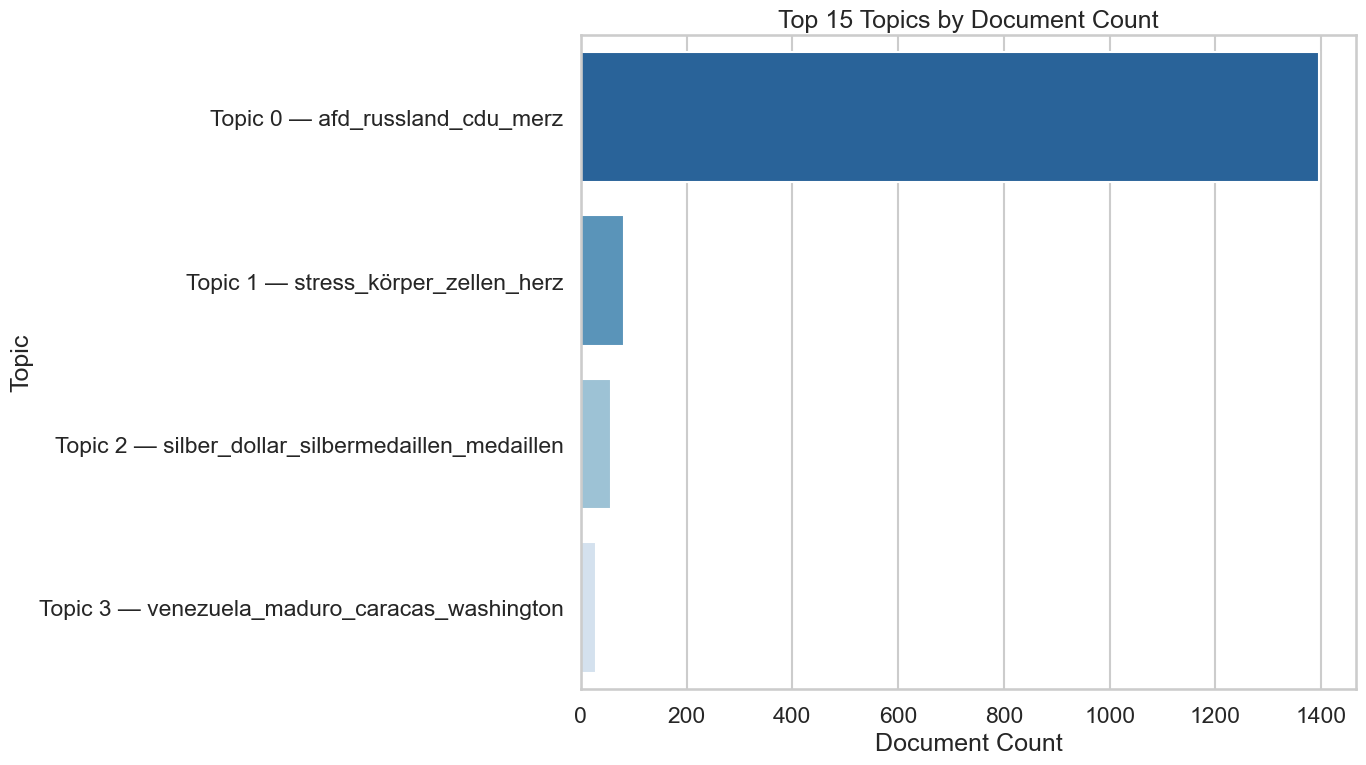

In [30]:
# Bar chart: first 15 non-outlier topics from the run model (with topic names)
run_result = result if "result" in globals() else result_compact
topic_info_run = run_result["topic_info"].copy()

top15_topics = topic_info_run.loc[topic_info_run["Topic"] != -1].head(15).copy()

# Clean topic name (remove leading "<topic_id>_")
top15_topics["TopicName"] = top15_topics["Name"].str.replace(r"^\d+_", "", regex=True)

# Combine topic id + readable name for y-axis
top15_topics["TopicLabel"] = (
    "Topic " + top15_topics["Topic"].astype(str) + " — " + top15_topics["TopicName"]
)

fig, ax = plt.subplots(figsize=(14, 8))
sns.barplot(
    data=top15_topics,
    x="Count",
    y="TopicLabel",
    palette="Blues_r",
    ax=ax
)

ax.set_title("Top 15 Topics by Document Count")
ax.set_xlabel("Document Count")
ax.set_ylabel("Topic")
plt.tight_layout()
plt.show()

Das war Gretas letzter Run. Nun: Topic 7 mit Keywords bestellung, shop, 90 euro, geschenk raus. Dann: reduce outlier von topic modelling. Dann: save newest models again + richards darstellung

In [ ]:
# check presence of the exact footer sentence in df_clean["Text"]
# relies on df_clean already being defined in the notebook

# the exact sentence (copy-paste from your prompt)
footer = "⁠In diesem Artikel wird u. a. auf Produkte der 9 Leben GmbH verlinkt. Für diese Links erhält COMPACT keinerlei Vergütungen."

# normalize by removing common zero-width characters that may be present
_zero_width_re = r"[\u200B\u200C\u200D\u2060]"
_texts = df_clean["Text"].astype("string").fillna("")
_texts_norm = _texts.str.replace(_zero_width_re, "", regex=True).str.strip()
_footer_norm = re.sub(_zero_width_re, "", footer)

# boolean mask for rows where the text ends with the exact footer (after normalization)
has_footer = _texts_norm.str.endswith(_footer_norm)

# show counts (True = contains exact footer, False = does not)
print("Presence value counts:")
print(has_footer.value_counts(dropna=False))

# optional: inspect a few matching rows (Date, Title) to verify
print("\nSample matching rows:")
display(df_clean.loc[has_footer, ["Date", "Title", "URL"]].head(10))